In [1]:
import os
import json
import numpy as np
import pandas as pd
import polar_diagrams

import plotly.io as pio
import plotly.graph_objects as go
import plotly.express as px

from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.utils import resample

np.random.seed(42)
pio.templates.default = "simple_white"
_COLOR_PLOT = '#2f2f2f'

In [2]:
__author__ = ['Aleksandar Anžel']
__copyright__ = ''
__credits__ = ['Aleksandar Anžel', 'Zewen Yang', 'Georges Hattab']
__license__ = 'GNU General Public License v3.0'
__version__ = '1.0.0'
__maintainer__ = 'Aleksandar Anžel'
__email__ = 'AnzelA@rki.de'
__status__ = 'Stable'

In [3]:
path_dashboard_data_root = os.path.join('..', 'data')
path_climate = os.path.join(
    path_dashboard_data_root, 'Case_Study_Climate', 'climate_models_temp.csv')
path_sample_analysis = os.path.join(
    path_dashboard_data_root, 'Case_Study_Wine', 'wine_sampled.csv')
path_ml_tuning = os.path.join(
    path_dashboard_data_root, 'Case_Study_Ecoli', "ecoli_evaluation.csv")
path_dbscan_results = 'DBSCAN_Results'

os.makedirs(path_dbscan_results, exist_ok=True)

# 1. Data Import and Quick Check

In [4]:
df_wine = pd.read_csv(path_sample_analysis)
string_reference_model_wine = 'Median'
df_wine

,Wine_0,Wine_1,Wine_10,Wine_11,Wine_12,Wine_13,Wine_14,Wine_15,Wine_16,Wine_17,...,Wine_19,Wine_2,Wine_3,Wine_4,Wine_5,Wine_6,Wine_7,Wine_8,Wine_9,Median
0,9.4000,9.8000,10.0000,11.4000,9.4000,10.2000,9.4000,10.7000,11.80000,10.30000,...,12.0000,10.00000,10.30000,9.40000,11.300,9.80000,11.5000,9.30000,9.5000,10.100000
1,0.6100,0.0810,0.0780,0.0450,0.0960,0.1000,0.0770,0.0860,0.06000,0.06700,...,0.0740,0.07800,0.08100,0.09200,0.049,0.06800,0.0500,0.06600,0.0530,0.077500
2,1.0000,0.0500,0.4900,0.0800,0.0000,0.2200,0.0400,0.0600,0.40000,0.25000,...,0.5300,0.24000,0.29000,0.45000,0.400,0.04000,0.2400,0.10000,0.3000,0.240000
3,0.9996,0.9966,0.9992,0.9949,0.9994,0.9967,0.9987,0.9965,0.99474,0.99721,...,0.9962,0.99692,0.99603,0.99918,0.996,0.99712,0.9934,0.99655,0.9965,0.996575
4,9.2000,7.0000,10.6000,6.4000,9.1000,8.6000,6.9000,7.5000,7.50000,5.90000,...,9.4000,9.00000,8.20000,10.00000,7.900,7.10000,5.0000,7.60000,7.1000,7.550000
5,32.0000,13.0000,20.0000,19.0000,11.0000,7.0000,7.0000,20.0000,12.00000,72.00000,...,6.0000,10.00000,27.00000,20.00000,38.000,19.00000,32.0000,27.00000,36.0000,19.500000
6,2.7400,3.3900,3.1900,3.4900,3.3500,3.2000,3.6900,3.3800,3.26000,3.33000,...,3.2000,3.29000,3.25000,3.15000,3.330,3.44000,3.7400,3.39000,2.9400,3.330000
7,3.4000,2.0000,3.2000,2.1000,2.6000,2.0000,3.0000,2.6000,2.20000,13.40000,...,2.4000,1.70000,1.60000,2.50000,2.200,2.10000,1.6000,1.50000,2.2000,2.200000
8,2.0000,0.5700,0.7000,0.4900,0.8300,0.5600,0.9100,0.5900,0.64000,0.54000,...,1.1300,0.67000,0.54000,0.43000,0.930,0.67000,0.6200,0.51000,1.6200,0.635000
9,69.0000,54.0000,78.0000,48.0000,26.0000,27.0000,27.0000,44.0000,20.00000,160.00000,...,18.0000,21.00000,45.00000,88.00000,67.000,27.00000,96.0000,55.00000,127.0000,46.500000


In [5]:
def list_make_data_for_sens_analysis():
    list_datasets = []
    list_examples = ['sample', 'climate', 'ml']
    list_diagram_types = ['taylor', 'mi_scaled', 'mi_normalized']

    for string_example in list_examples:
        df_input = None
        if string_example == 'sample':
            _STRING_REFERENCE_MODEL = 'Median'
            _DICT_MI_PARAMETERS = dict(
                string_entropy_method="auto",
                int_mi_n_neighbors=3,
                bool_discrete_reference_model=False,
                discrete_models=False,
                int_random_state=42,
            )
            df_input = pd.read_csv(path_sample_analysis)

        elif string_example == 'climate':
            _STRING_REFERENCE_MODEL = "Observation"
            _DICT_MI_PARAMETERS = dict(
                string_entropy_method="auto",
                int_mi_n_neighbors=3,
                bool_discrete_reference_model=False,
                discrete_models=False,
                int_random_state=42,
            )
            df_input = pd.read_csv(path_climate)

        else:
            _STRING_REFERENCE_MODEL = "Ground_Truth"
            _DICT_MI_PARAMETERS = dict(
                string_entropy_method="auto",
                int_mi_n_neighbors=3,
                bool_discrete_reference_model=True,
                discrete_models=True,
                int_random_state=42,
            )
            df_input = pd.read_csv(path_ml_tuning)

        for string_diagram_type in list_diagram_types:
            if string_diagram_type == 'taylor':
                _LIST_MEASURES = ["Standard Deviation", "Correlation", "CRMSE"]
                df_polar_calculated = polar_diagrams.df_calculate_td_properties(
                    df_input, _STRING_REFERENCE_MODEL)

            elif string_diagram_type == 'mi_scaled':
                _LIST_MEASURES = ["Entropy", "Scaled MI", "VI"]
                df_polar_calculated = polar_diagrams.df_calculate_mid_properties(
                    df_input,
                    _STRING_REFERENCE_MODEL,
                    dict_mi_parameters=_DICT_MI_PARAMETERS,
                )

            else:
                _LIST_MEASURES = ["Root Entropy", "Normalized MI", "RVI"]
                df_polar_calculated = polar_diagrams.df_calculate_mid_properties(
                    df_input,
                    _STRING_REFERENCE_MODEL,
                    dict_mi_parameters=_DICT_MI_PARAMETERS,
                )

            list_datasets.append(
                {
                    "NAME": string_example + "_" + string_diagram_type,
                    "DF_INPUT": df_polar_calculated,
                    "STRING_REFERENCE_MODEL": _STRING_REFERENCE_MODEL,
                    "LIST_MEASURES": _LIST_MEASURES
                },
            )

    return list_datasets

In [6]:
list_datasets = list_make_data_for_sens_analysis()


# 2. DBSCAN Sensitivity Analysis
Revision 1 requirement: Assess the influence of DBSCAN parameter selection on the clusters in the overview diagram of the proposed dashboard.

In [7]:
def auto_dbscan(X):
    n_dims = X.shape[1]
    n_samples = X.shape[0]

    k = max(2, min(2 * n_dims - 1, int(np.log(n_samples))))
    k = min(k, n_samples - 1)

    if k < 2:
        return 0.5, 2

    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nbrs.kneighbors(X)
    k_distances = np.sort(distances[:, k - 1])

    if len(k_distances) < 3:
        return float(np.median(k_distances)), k

    diffs = np.diff(k_distances)
    second_diffs = np.diff(diffs)
    elbow_idx = np.argmax(second_diffs) + 1
    eps = k_distances[elbow_idx]

    min_pts = k
    return eps, min_pts


def prepare_dbscan_input(df_left_input, string_reference_model, list_measures):
    df_reference_row = df_left_input.loc[
        df_left_input["Model"] == string_reference_model
    ]

    if df_reference_row.shape[0] != 1:
        raise ValueError(
            f"Expected exactly one reference row for model "
            f"'{string_reference_model}', got {df_reference_row.shape[0]}"
        )

    df_input_no_reference = df_left_input.drop(df_reference_row.index)[
        list_measures
    ].copy()

    X = df_input_no_reference.values

    return {
        "df_reference_row": df_reference_row,
        "df_input_no_reference": df_input_no_reference,
        "X": X,
    }


def run_dbscan_with_auto_params(df_left_input, string_reference_model, list_measures):
    prepared = prepare_dbscan_input(
        df_left_input=df_left_input,
        string_reference_model=string_reference_model,
        list_measures=list_measures,
    )

    df_reference_row = prepared["df_reference_row"]
    df_input_no_reference = prepared["df_input_no_reference"]
    X = prepared["X"]

    float_eps, int_min_samples = auto_dbscan(X)

    constructor_DBSCAN = DBSCAN(
        eps=float_eps,
        min_samples=int_min_samples,
        n_jobs=-1,
    )
    constructor_DBSCAN.fit(X)

    labels_no_reference = list(constructor_DBSCAN.labels_)

    labels_with_reference = list(labels_no_reference)
    labels_with_reference.insert(
        df_reference_row.index.values[0],
        df_left_input.shape[0],
    )

    core_mask = np.zeros_like(constructor_DBSCAN.labels_, dtype=bool)
    if hasattr(constructor_DBSCAN, "core_sample_indices_"):
        core_mask[constructor_DBSCAN.core_sample_indices_] = True

    return {
        "eps": float_eps,
        "min_samples": int_min_samples,
        "df_reference_row": df_reference_row,
        "df_input_no_reference": df_input_no_reference,
        "X": X,
        "dbscan_model": constructor_DBSCAN,
        "labels_no_reference": labels_no_reference,
        "labels_with_reference": labels_with_reference,
        "core_mask": core_mask,
    }

In [8]:
def compute_validation_metrics(X, dbscan_model, core_mask):
    labels = dbscan_model.labels_
    noise_mask = labels == -1

    n_noise = int(np.sum(noise_mask))
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_frac = n_noise / len(labels)

    n_core = int(np.sum(core_mask))
    n_border = int(np.sum((labels != -1) & (~core_mask)))

    valid_mask = labels != -1
    X_valid = X[valid_mask]
    labels_valid = labels[valid_mask]

    if len(set(labels_valid)) >= 2:
        silhouette = silhouette_score(X_valid, labels_valid)
        davies_bouldin = davies_bouldin_score(X_valid, labels_valid)
        calinski_harabasz = calinski_harabasz_score(X_valid, labels_valid)
    else:
        silhouette = np.nan
        davies_bouldin = np.nan
        calinski_harabasz = np.nan

    return {
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_frac": noise_frac,
        "n_core": n_core,
        "n_border": n_border,
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
    }


def sensitivity_sweep_for_dataset(
    df_left_input,
    string_reference_model,
    list_measures,
    eps_center,
    min_samples_center,
    eps_range_ratio=0.30,
    eps_steps=41,
    min_samples_offsets=(-2, -1, 0, 1, 2),
):
    prepared = prepare_dbscan_input(
        df_left_input=df_left_input,
        string_reference_model=string_reference_model,
        list_measures=list_measures,
    )

    X = prepared["X"]

    eps_values = np.linspace(
        eps_center * (1 - eps_range_ratio),
        eps_center * (1 + eps_range_ratio),
        eps_steps,
    )

    rows = []

    for eps in eps_values:
        for offset in min_samples_offsets:
            min_samples = max(2, min_samples_center + offset)

            db = DBSCAN(
                eps=float(eps),
                min_samples=int(min_samples),
                n_jobs=-1,
            )
            db.fit(X)

            core_mask = np.zeros_like(db.labels_, dtype=bool)
            if hasattr(db, "core_sample_indices_"):
                core_mask[db.core_sample_indices_] = True

            metrics = compute_validation_metrics(X, db, core_mask)

            rows.append(
                {
                    "eps": float(eps),
                    "min_samples": int(min_samples),
                    **metrics,
                }
            )

    return pd.DataFrame(rows)


def bootstrap_stability_for_dataset(
    df_left_input,
    string_reference_model,
    list_measures,
    eps,
    min_samples,
    n_boot=100,
    sample_frac=0.8,
    random_state=42,
):
    prepared = prepare_dbscan_input(
        df_left_input=df_left_input,
        string_reference_model=string_reference_model,
        list_measures=list_measures,
    )

    X = prepared["X"]

    db_full = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    db_full.fit(X)
    full_labels = db_full.labels_

    rng = np.random.RandomState(random_state)
    rows = []

    for i in range(n_boot):
        idx = resample(
            np.arange(X.shape[0]),
            replace=False,
            n_samples=max(3, int(X.shape[0] * sample_frac)),
            random_state=rng.randint(0, 10_000_000),
        )

        X_sub = X[idx]

        db_sub = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        db_sub.fit(X_sub)
        sub_labels = db_sub.labels_

        full_labels_sub = full_labels[idx]
        ari_vs_full = adjusted_rand_score(full_labels_sub, sub_labels)

        rows.append(
            {
                "bootstrap_iter": i,
                "sample_size": len(idx),
                "ari_vs_full": float(ari_vs_full),
                "n_clusters": len(set(sub_labels)) - (1 if -1 in sub_labels else 0),
                "noise_frac": float(np.mean(sub_labels == -1)),
            }
        )

    return pd.DataFrame(rows)

In [9]:
def plot_k_distance_for_dataset(X, k, eps, dataset_name):
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nbrs.kneighbors(X)
    k_distances = np.sort(distances[:, k - 1])

    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=np.arange(len(k_distances)),
            y=k_distances,
            mode="lines",
            name="k-distance",
        )
    )
    fig.add_hline(
        y=eps,
        line_dash="dash",
        annotation_text=f"chosen eps = {eps:.3f}",
        annotation_position="top left",
    )
    fig.update_layout(title=f"k-distance elbow ({dataset_name})")
    fig.update_xaxes(title_text="Sorted pts")
    fig.update_yaxes(title_text="k-dist")
    return fig


def plot_silhouette_line(df_sweep, eps0, min_samples0, dataset_name):
    df_plot = df_sweep[df_sweep["min_samples"] == min_samples0].copy()

    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=df_plot["eps"],
            y=df_plot["silhouette"],
            mode="lines+markers",
            name=f"min_samples={min_samples0}",
        )
    )
    fig.add_vline(
        x=eps0,
        line_dash="dash",
        annotation_text=f"chosen eps = {eps0:.3f}",
        annotation_position="top right",
    )
    fig.update_layout(
        title=f"Silhouette vs eps ({dataset_name})",
        legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="center", x=0.5),
    )
    fig.update_xaxes(title_text="eps")
    fig.update_yaxes(title_text="silhouette")
    fig.update_traces(cliponaxis=False)
    return fig


def plot_heatmap(df_sweep, value_col, title_text, colorbar_title):
    pivot = df_sweep.pivot_table(index="min_samples", columns="eps", values=value_col)
    pivot = pivot.sort_index()

    fig = go.Figure(
        data=go.Heatmap(
            z=pivot.values,
            x=np.round(pivot.columns.values, 4),
            y=pivot.index.values,
            colorbar=dict(title=colorbar_title),
        )
    )
    fig.update_layout(title=title_text)
    fig.update_xaxes(title_text="eps")
    fig.update_yaxes(title_text="min_samp")
    return fig


def plot_bootstrap_hist(df_boot, dataset_name):
    fig = go.Figure()
    fig.add_trace(
        go.Histogram(
            x=df_boot["ari_vs_full"],
            nbinsx=20,
            name="ARI",
        )
    )
    fig.update_layout(title=f"Bootstrap stability ({dataset_name})")
    fig.update_xaxes(title_text="ARI")
    fig.update_yaxes(title_text="Count")
    return fig

In [14]:
def run_dbscan_validation_batch(
    list_datasets,
    output_dir=path_dbscan_results,
    eps_range_ratio=0.30,
    eps_steps=41,
    min_samples_offsets=(-2, -1, 0, 1, 2),
    n_boot=100,
    sample_frac=0.8,
    random_state=42,
):
    all_results = {}
    summary_rows = []

    for i, dataset in enumerate(list_datasets):
        dataset_name = dataset.get("NAME", f"dataset_{i+1}")
        df_left_input = dataset["DF_INPUT"]
        string_reference_model = dataset["STRING_REFERENCE_MODEL"]
        list_measures = dataset["LIST_MEASURES"]

        dataset_dir = os.path.join(output_dir, dataset_name)
        os.makedirs(dataset_dir, exist_ok=True)

        run_result = run_dbscan_with_auto_params(
            df_left_input=df_left_input,
            string_reference_model=string_reference_model,
            list_measures=list_measures,
        )

        eps0 = run_result["eps"]
        min_samples0 = run_result["min_samples"]
        X = run_result["X"]

        metrics0 = compute_validation_metrics(
            X=X,
            dbscan_model=run_result["dbscan_model"],
            core_mask=run_result["core_mask"],
        )

        df_sweep = sensitivity_sweep_for_dataset(
            df_left_input=df_left_input,
            string_reference_model=string_reference_model,
            list_measures=list_measures,
            eps_center=eps0,
            min_samples_center=min_samples0,
            eps_range_ratio=eps_range_ratio,
            eps_steps=eps_steps,
            min_samples_offsets=min_samples_offsets,
        )

        df_boot = bootstrap_stability_for_dataset(
            df_left_input=df_left_input,
            string_reference_model=string_reference_model,
            list_measures=list_measures,
            eps=eps0,
            min_samples=min_samples0,
            n_boot=n_boot,
            sample_frac=sample_frac,
            random_state=random_state,
        )

        fig1 = plot_k_distance_for_dataset(X, k=min_samples0, eps=eps0, dataset_name=dataset_name)
        fig2 = plot_silhouette_line(df_sweep, eps0=eps0, min_samples0=min_samples0, dataset_name=dataset_name)
        fig3 = plot_heatmap(df_sweep, "n_clusters", f"Clusters across eps/min_samples ({dataset_name})", "Clusters")
        fig4 = plot_heatmap(df_sweep, "noise_frac", f"Noise fraction across eps/min_samples ({dataset_name})", "Noise")
        fig5 = plot_heatmap(df_sweep, "silhouette", f"Silhouette across eps/min_samples ({dataset_name})", "Silhouette")
        fig6 = plot_bootstrap_hist(df_boot, dataset_name=dataset_name)

        df_sweep.to_csv(os.path.join(dataset_dir, "sensitivity_sweep.csv"), index=False)
        df_boot.to_csv(os.path.join(dataset_dir, "bootstrap_stability.csv"), index=False)

        fig1.write_html(os.path.join(dataset_dir, "k_distance.html"))
        fig2.write_html(os.path.join(dataset_dir, "silhouette_vs_eps.html"))
        fig3.write_html(os.path.join(dataset_dir, "clusters_heatmap.html"))
        fig4.write_html(os.path.join(dataset_dir, "noise_heatmap.html"))
        fig5.write_html(os.path.join(dataset_dir, "silhouette_heatmap.html"))
        fig6.write_html(os.path.join(dataset_dir, "bootstrap_ari_hist.html"))

        fig1.write_image(os.path.join(dataset_dir, "k_distance.pdf"))
        fig2.write_image(os.path.join(dataset_dir, "silhouette_vs_eps.pdf"))
        fig3.write_image(os.path.join(dataset_dir, "clusters_heatmap.pdf"))
        fig4.write_image(os.path.join(dataset_dir, "noise_heatmap.pdf"))
        fig5.write_image(os.path.join(dataset_dir, "silhouette_heatmap.pdf"))
        fig6.write_image(os.path.join(dataset_dir, "bootstrap_ari_hist.pdf"))

        summary = {
            "dataset_name": dataset_name,
            "reference_model": string_reference_model,
            "n_input_rows": int(df_left_input.shape[0]),
            "n_clustered_rows": int(X.shape[0]),
            "n_measures": int(len(list_measures)),
            "eps0": float(eps0),
            "min_samples0": int(min_samples0),
            "n_clusters": int(metrics0["n_clusters"]),
            "n_noise": int(metrics0["n_noise"]),
            "noise_frac": float(metrics0["noise_frac"]),
            "n_core": int(metrics0["n_core"]),
            "n_border": int(metrics0["n_border"]),
            "silhouette": float(metrics0["silhouette"]) if pd.notnull(metrics0["silhouette"]) else None,
            "davies_bouldin": float(metrics0["davies_bouldin"]) if pd.notnull(metrics0["davies_bouldin"]) else None,
            "calinski_harabasz": float(metrics0["calinski_harabasz"]) if pd.notnull(metrics0["calinski_harabasz"]) else None,
            "bootstrap_ari_mean": float(df_boot["ari_vs_full"].mean()),
            "bootstrap_ari_std": float(df_boot["ari_vs_full"].std()),
            "bootstrap_ari_median": float(df_boot["ari_vs_full"].median()),
        }

        with open(os.path.join(dataset_dir, "validation_summary.json"), "w") as f:
            json.dump(summary, f, indent=2)

        summary_rows.append(summary)

        all_results[dataset_name] = {
            "run_result": run_result,
            "metrics0": metrics0,
            "df_sweep": df_sweep,
            "df_boot": df_boot,
            "figures": {
                "k_distance": fig1,
                "silhouette_vs_eps": fig2,
                "clusters_heatmap": fig3,
                "noise_heatmap": fig4,
                "silhouette_heatmap": fig5,
                "bootstrap_ari_hist": fig6,
            },
            "summary": summary,
        }

    df_summary = pd.DataFrame(summary_rows)
    df_summary.to_csv(os.path.join(output_dir, "all_list_datasets_summary.csv"), index=False)

    return all_results, df_summary

In [15]:
ALL_RESULTS, DF_SUMMARY = run_dbscan_validation_batch(
    list_datasets=list_datasets,
    output_dir=path_dbscan_results,
    eps_range_ratio=0.30,
    eps_steps=41,
    min_samples_offsets=(-2, -1, 0, 1, 2),
    n_boot=100,
    sample_frac=0.8,
    random_state=42,
)

DF_SUMMARY

RuntimeError: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome



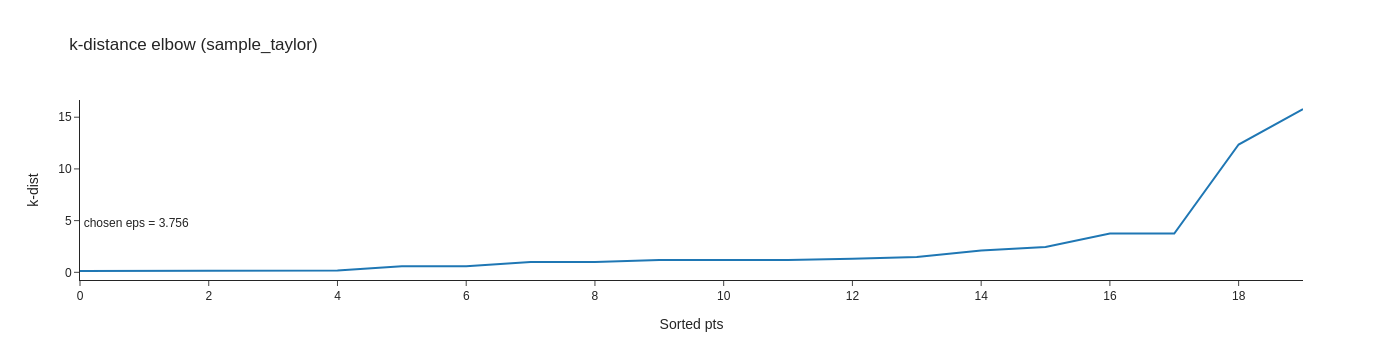

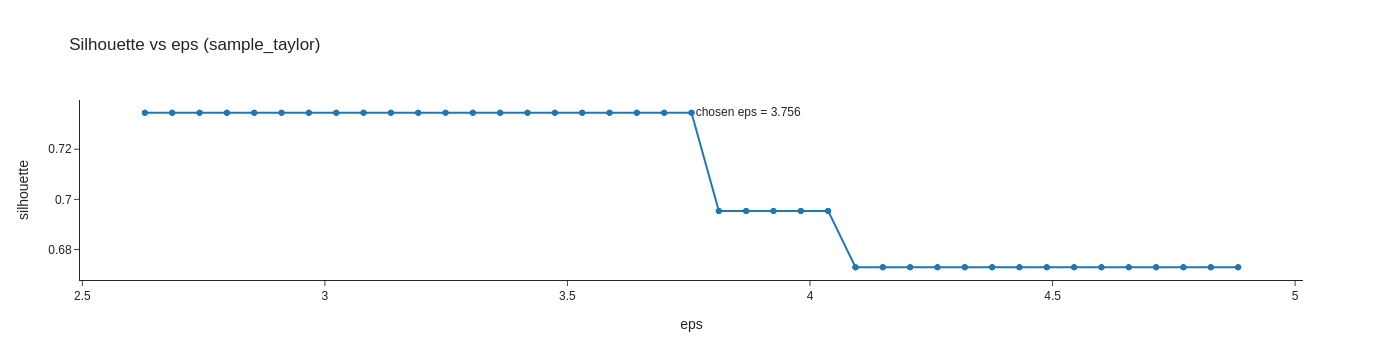

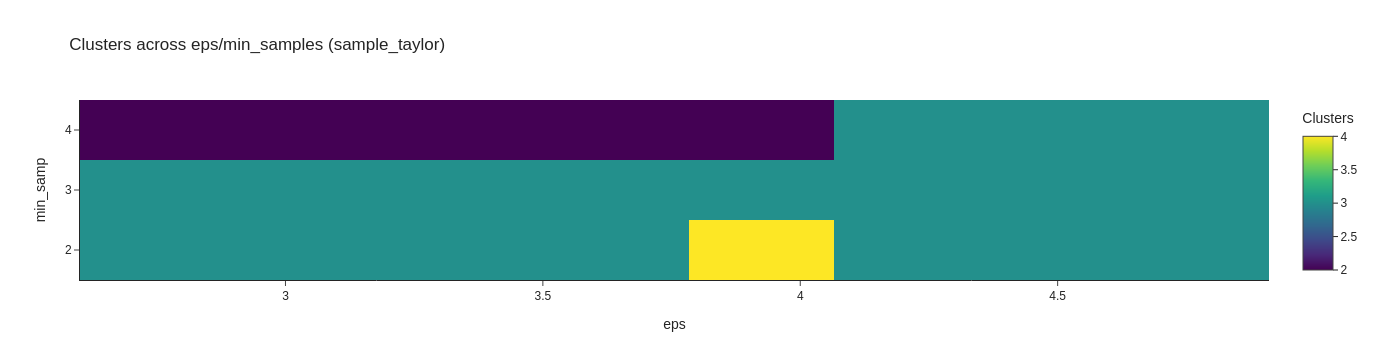

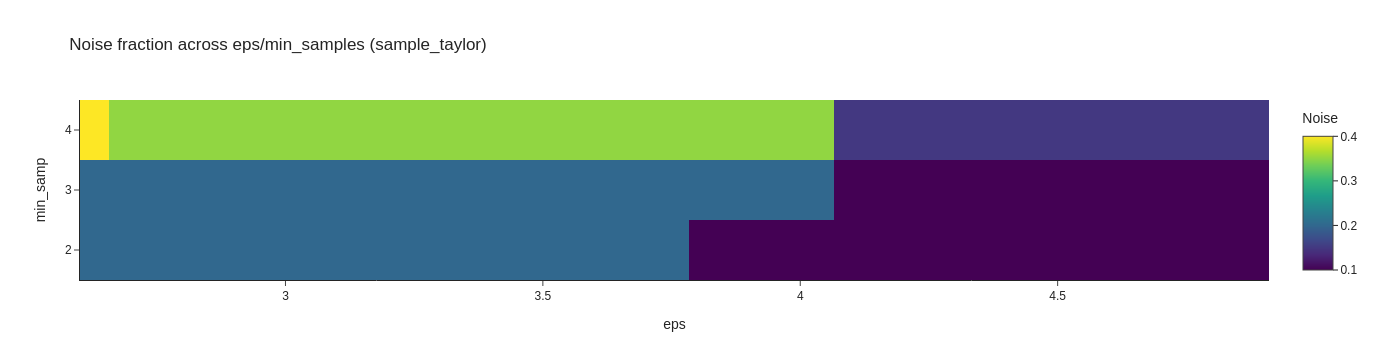

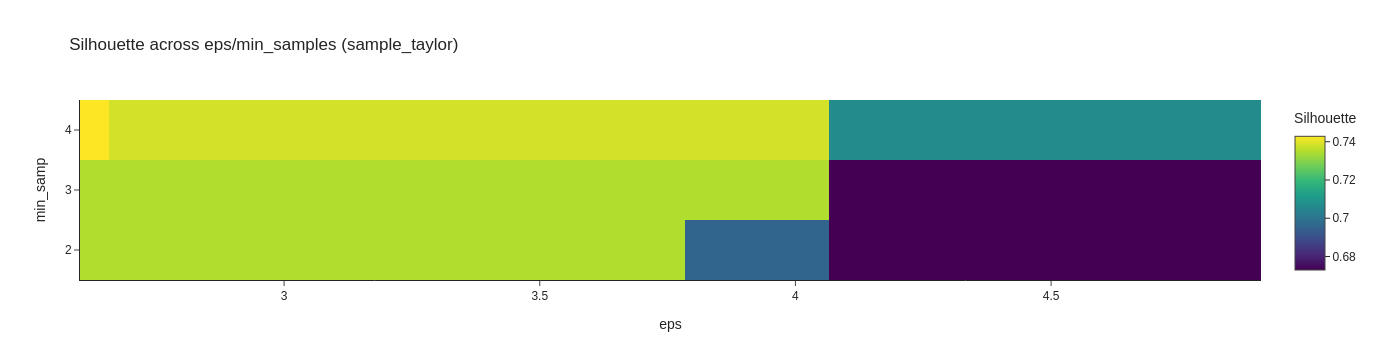

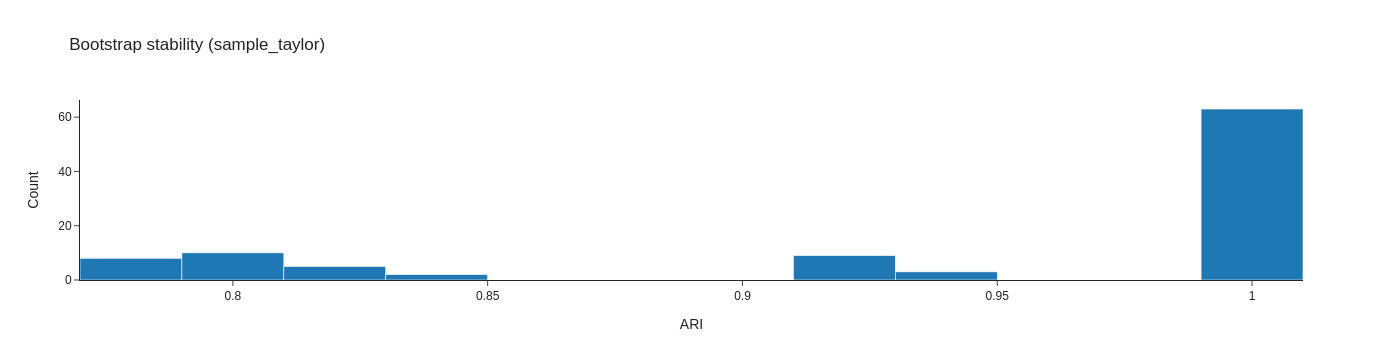

In [13]:
dataset_name = list_datasets[0].get("NAME", "climate")

ALL_RESULTS[dataset_name]["figures"]["k_distance"].show()
ALL_RESULTS[dataset_name]["figures"]["silhouette_vs_eps"].show()
ALL_RESULTS[dataset_name]["figures"]["clusters_heatmap"].show()
ALL_RESULTS[dataset_name]["figures"]["noise_heatmap"].show()
ALL_RESULTS[dataset_name]["figures"]["silhouette_heatmap"].show()
ALL_RESULTS[dataset_name]["figures"]["bootstrap_ari_hist"].show()